# 🔍 Visualize quá trình phân loại biển báo — HOG + RF/SVM

Notebook này dùng để **nhìn rõ pipeline phân loại**:

1. Đọc ảnh gốc
2. Chuyển grayscale
3. Resize về đúng kích thước lúc train
4. Trích xuất đặc trưng HOG và hiển thị HOG image
5. Đưa vector HOG vào model
6. Hiển thị nhãn dự đoán, confidence / score và Top-k lớp gần nhất

> Đặt file notebook này trong thư mục: `notebook_demo/visualize_classification_process.ipynb`

In [1]:
from pathlib import Path

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import resize

## 1. Khai báo đường dẫn project

In [2]:
# Thư mục gốc project của bạn
PROJECT_ROOT = Path(r"E:\Nam_3_HK2\ThiGiac\DoAn\demo")

DATA_DIR   = PROJECT_ROOT / "data"
TEST_DIR   = DATA_DIR / "test"
MODELS_DIR = PROJECT_ROOT / "models"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TEST_DIR     :", TEST_DIR)
print("MODELS_DIR   :", MODELS_DIR)

PROJECT_ROOT: E:\Nam_3_HK2\ThiGiac\DoAn\demo
TEST_DIR     : E:\Nam_3_HK2\ThiGiac\DoAn\demo\data\test
MODELS_DIR   : E:\Nam_3_HK2\ThiGiac\DoAn\demo\models


## 2. Chọn model muốn visualize

In [3]:
MODEL_FILES = {
    "RF_6x3" : "HOG_RandomForest_6x3.joblib",
    "RF_8x2" : "HOG_RandomForest_8x2.joblib",
    "SVM_6x3": "HOG_SVM_6x3.joblib",
    "SVM_8x2": "HOG_SVM_8x2.joblib",
}

# Đổi key ở đây nếu muốn dùng model khác: RF_6x3, RF_8x2, SVM_6x3, SVM_8x2
MODEL_KEY = "RF_6x3"
MODEL_PATH = MODELS_DIR / MODEL_FILES[MODEL_KEY]

payload = joblib.load(MODEL_PATH)

model      = payload["model"]
le         = payload["label_encoder"]
HOG_PARAMS = payload["hog_params"]
IMAGE_SIZE = payload["image_size"]

print(f"✅ Loaded model : {MODEL_KEY}")
print(f"✅ Model type   : {type(model).__name__}")
print(f"✅ Classes      : {list(le.classes_)}")
print(f"✅ Image size   : {IMAGE_SIZE}")
print(f"✅ HOG params   : {HOG_PARAMS}")

✅ Loaded model : RF_6x3
✅ Model type   : RandomForestClassifier
✅ Classes      : ['Cam', 'Chidan', 'Hieulenh', 'Nguyhiem', 'Phu']
✅ Image size   : (128, 128)
✅ HOG params   : {'orientations': 9, 'pixels_per_cell': (6, 6), 'cells_per_block': (3, 3), 'block_norm': 'L2-Hys'}


## 3. Chọn ảnh cần phân loại

In [4]:
# Cách 1: nhập trực tiếp đường dẫn ảnh
IMAGE_PATH = TEST_DIR / "Nguyhiem" / "Nguyhiem_3.jpeg"

# Cách 2: nếu muốn tự lấy 1 ảnh đầu tiên trong thư mục test
# IMAGE_PATH = next(TEST_DIR.rglob("*.jpeg"))

print("IMAGE_PATH:", IMAGE_PATH)

IMAGE_PATH: E:\Nam_3_HK2\ThiGiac\DoAn\demo\data\test\Nguyhiem\Nguyhiem_3.jpeg


## 4. Hàm xử lý ảnh và trích xuất HOG có visualize

In [5]:
def enhance_hog_image(hog_image: np.ndarray) -> np.ndarray:
    image = np.asarray(hog_image, dtype=np.float32)
    image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)
    image = np.maximum(image, 0.0)

    if float(image.max()) <= float(image.min()):
        return np.full((*image.shape, 3), 246, dtype=np.uint8)

    active = image[image > 0]
    if active.size == 0:
        return np.full((*image.shape, 3), 246, dtype=np.uint8)

    low = float(np.percentile(active, 5.0))
    high = float(np.percentile(active, 99.5))
    if high <= low:
        low = 0.0
        high = float(active.max())

    image = np.clip((image - low) / (high - low + 1e-8), 0.0, 1.0)
    image = np.power(image, 0.32)
    image_u8 = np.clip(image * 255.0, 0, 255).astype(np.uint8)
    image_u8 = cv2.dilate(image_u8, np.ones((2, 2), dtype=np.uint8), iterations=1)

    color_bgr = cv2.applyColorMap(image_u8, cv2.COLORMAP_TURBO)
    color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)
    canvas = np.full((*image_u8.shape, 3), 246, dtype=np.uint8)
    mask = image_u8 > 10
    alpha = (image_u8.astype(np.float32) / 255.0)[..., None]
    blended = canvas.astype(np.float32) * (1.0 - alpha) + color_rgb.astype(np.float32) * alpha
    canvas[mask] = blended[mask].astype(np.uint8)
    return canvas


def preprocess_and_extract_hog(image_path, image_size, hog_params):
    """Return intermediate images for visualization."""
    img_original = imread(image_path)

    if img_original.ndim == 3:
        img_gray = rgb2gray(img_original)
    else:
        img_gray = img_original.astype(float)
        if img_gray.max() > 1:
            img_gray = img_gray / 255.0

    img_resized = resize(img_gray, image_size, anti_aliasing=True)

    features, hog_image = hog(
        img_resized,
        visualize=True,
        **hog_params
    )

    hog_image_enhanced = enhance_hog_image(hog_image)

    return {
        "original": img_original,
        "gray": img_gray,
        "resized": img_resized,
        "features": features,
        "hog_image": hog_image_enhanced,
    }


## 5. Visualize từng bước tiền xử lý + HOG

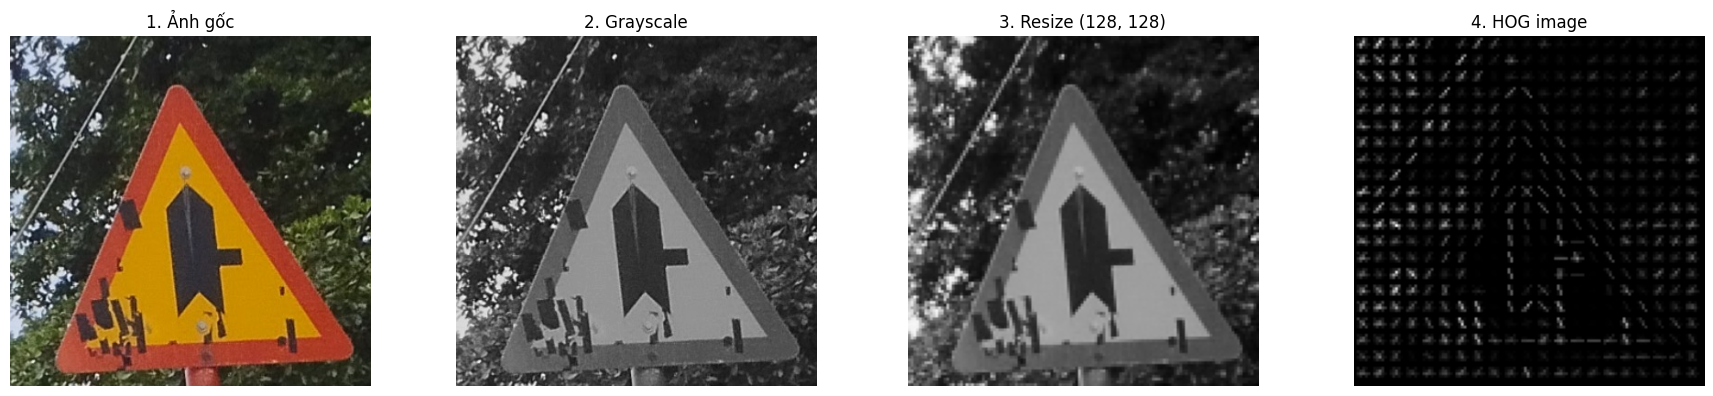

Số chiều vector HOG: 29241
10 giá trị HOG đầu tiên:
[0.21959156 0.08576957 0.07694661 0.12617047 0.11564447 0.02793256
 0.06143597 0.04160744 0.05426769 0.21959156]


In [6]:
info = preprocess_and_extract_hog(IMAGE_PATH, IMAGE_SIZE, HOG_PARAMS)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(info["original"])
axes[0].set_title("1. Ảnh gốc")
axes[0].axis("off")

axes[1].imshow(info["gray"], cmap="gray")
axes[1].set_title("2. Grayscale")
axes[1].axis("off")

axes[2].imshow(info["resized"], cmap="gray")
axes[2].set_title(f"3. Resize {IMAGE_SIZE}")
axes[2].axis("off")

axes[3].imshow(info["hog_image"])
axes[3].set_title("4. HOG image")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("Số chiều vector HOG:", info["features"].shape[0])
print("10 giá trị HOG đầu tiên:")
print(info["features"][:10])

## 6. Visualize vector đặc trưng HOG

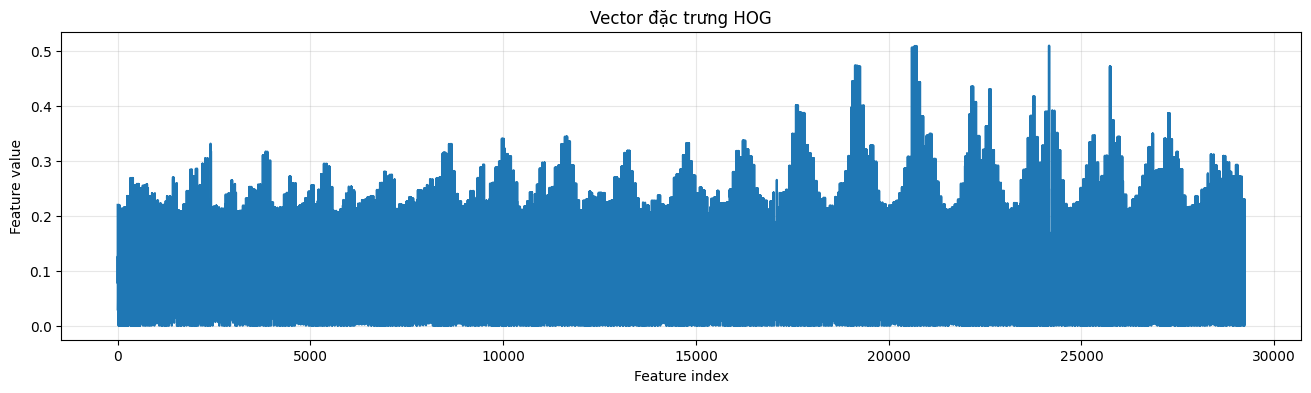

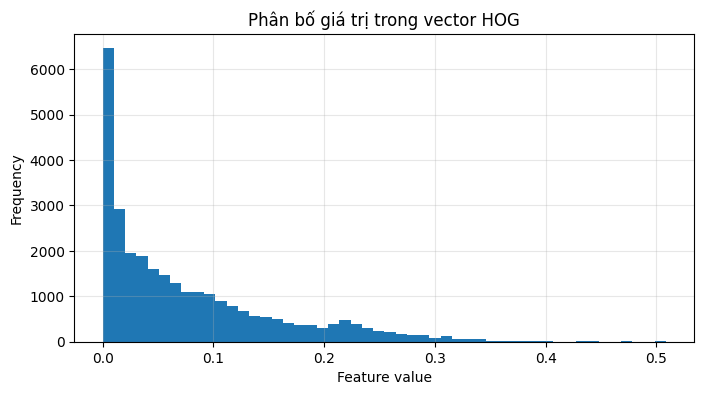

In [7]:
features = info["features"]

plt.figure(figsize=(16, 4))
plt.plot(features)
plt.title("Vector đặc trưng HOG")
plt.xlabel("Feature index")
plt.ylabel("Feature value")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(features, bins=50)
plt.title("Phân bố giá trị trong vector HOG")
plt.xlabel("Feature value")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Dự đoán và visualize score / probability

🏷️ Dự đoán: Nguyhiem
Loại score: probability
Top-5 lớp:
1. Nguyhiem                       51.3850%
2. Hieulenh                       14.7467%
3. Cam                            14.0472%
4. Chidan                         11.9380%
5. Phu                            7.8832%


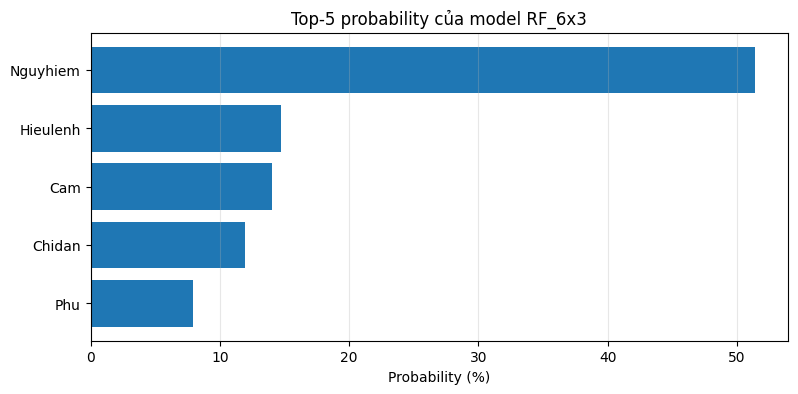

In [8]:
def get_model_scores(model, x):
    """
    RF thường có predict_proba.
    SVM có thể có predict_proba hoặc decision_function.
    Hàm này chuẩn hóa output để vẽ Top-k.
    """
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(x)[0]
        score_type = "probability"
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(x)[0]
        if np.ndim(scores) == 0:
            scores = np.array([-scores, scores])
        score_type = "decision score"
    else:
        scores = None
        score_type = "none"
    return scores, score_type

x = features.reshape(1, -1)
pred_enc = model.predict(x)[0]
pred_label = le.inverse_transform([pred_enc])[0]

scores, score_type = get_model_scores(model, x)

print(f"🏷️ Dự đoán: {pred_label}")
print(f"Loại score: {score_type}")

if scores is not None:
    top_k = min(5, len(scores))
    top_idx = np.argsort(scores)[::-1][:top_k]

    print(f"Top-{top_k} lớp:")
    for rank, idx in enumerate(top_idx, start=1):
        label = le.inverse_transform([idx])[0]
        value = scores[idx]
        suffix = "%" if score_type == "probability" else ""
        shown_value = value * 100 if score_type == "probability" else value
        print(f"{rank}. {label:30s} {shown_value:.4f}{suffix}")

    labels = [le.inverse_transform([idx])[0] for idx in top_idx][::-1]
    values = [scores[idx] for idx in top_idx][::-1]
    if score_type == "probability":
        values = [v * 100 for v in values]

    plt.figure(figsize=(9, 4))
    plt.barh(labels, values)
    plt.title(f"Top-{top_k} {score_type} của model {MODEL_KEY}")
    plt.xlabel("Probability (%)" if score_type == "probability" else "Decision score")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()
else:
    print("Model không hỗ trợ predict_proba hoặc decision_function để visualize score.")

## 8. Gom toàn bộ pipeline vào một hàm visualize

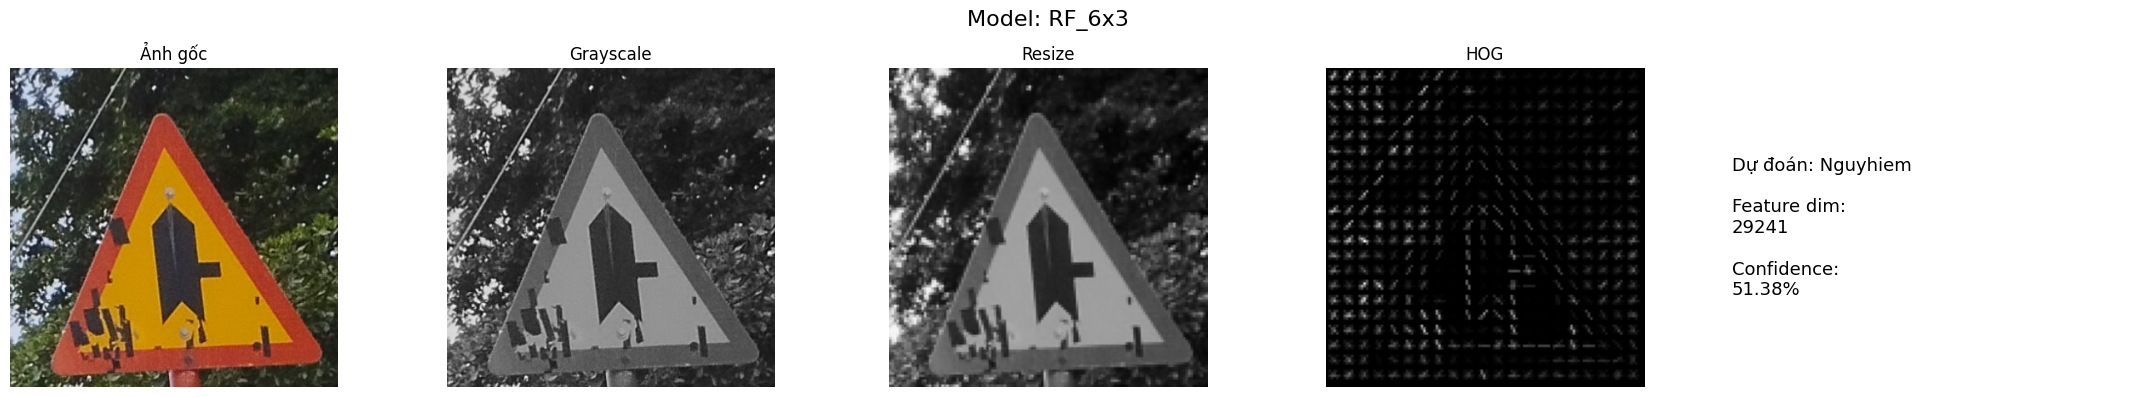

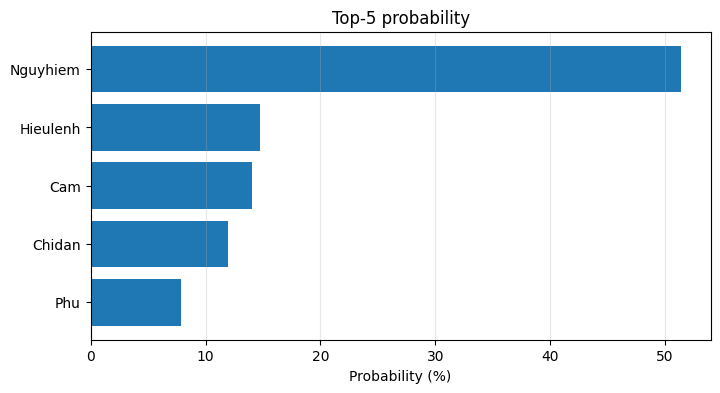

'Nguyhiem'

In [9]:
def visualize_classification(image_path, model, le, image_size, hog_params, title=None, top_k=5):
    info = preprocess_and_extract_hog(image_path, image_size, hog_params)
    x = info["features"].reshape(1, -1)

    pred_enc = model.predict(x)[0]
    pred_label = le.inverse_transform([pred_enc])[0]
    scores, score_type = get_model_scores(model, x)

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))

    axes[0].imshow(info["original"])
    axes[0].set_title("Ảnh gốc")
    axes[0].axis("off")

    axes[1].imshow(info["gray"], cmap="gray")
    axes[1].set_title("Grayscale")
    axes[1].axis("off")

    axes[2].imshow(info["resized"], cmap="gray")
    axes[2].set_title("Resize")
    axes[2].axis("off")

    axes[3].imshow(info["hog_image"])
    axes[3].set_title("HOG")
    axes[3].axis("off")

    axes[4].axis("off")

    text = (
        f"Dự đoán: {pred_label}\n\n"
        f"Feature dim:\n{info['features'].shape[0]}"
    )

    if scores is not None:
        if score_type == "probability":
            confidence = scores[pred_enc] * 100
            text += f"\n\nConfidence:\n{confidence:.2f}%"
        else:
            text += f"\n\nScore:\n{scores[pred_enc]:.4f}"

    axes[4].text(0.05, 0.5, text, fontsize=13, va="center")

    if title is None:
        title = Path(image_path).name

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

    if scores is not None:
        top_k = min(top_k, len(scores))
        top_idx = np.argsort(scores)[::-1][:top_k]

        labels = [le.inverse_transform([idx])[0] for idx in top_idx][::-1]
        values = [scores[idx] for idx in top_idx][::-1]

        if score_type == "probability":
            values = [v * 100 for v in values]

        plt.figure(figsize=(8, 4))
        plt.barh(labels, values)
        plt.title(f"Top-{top_k} {score_type}")
        plt.xlabel("Probability (%)" if score_type == "probability" else "Decision score")
        plt.grid(True, axis="x", alpha=0.3)
        plt.show()

    return pred_label


visualize_classification(
    IMAGE_PATH,
    model,
    le,
    IMAGE_SIZE,
    HOG_PARAMS,
    title=f"Model: {MODEL_KEY}"
)

## 9. Visualize nhiều ảnh trong thư mục test

Tìm thấy 6 ảnh để visualize


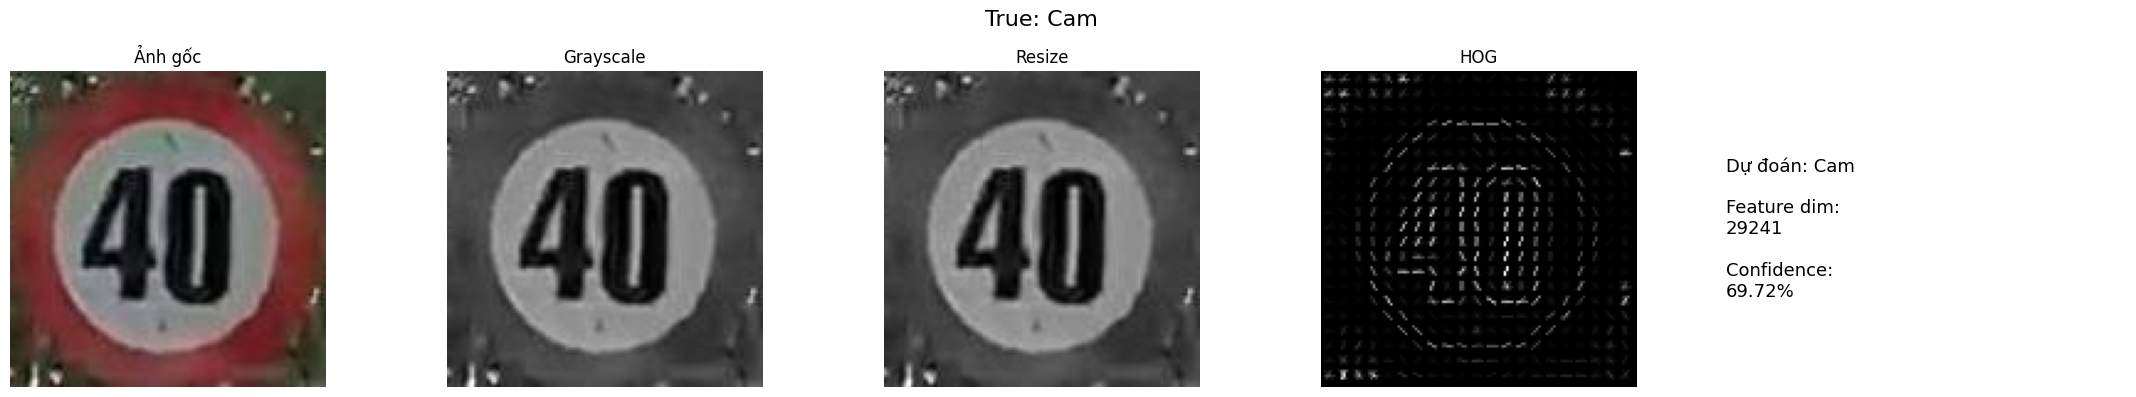

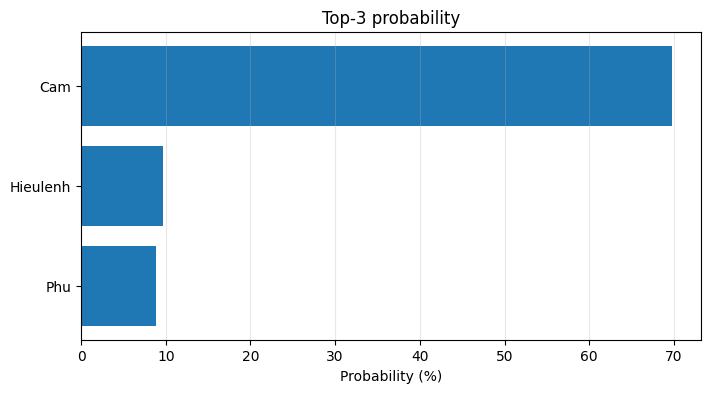

True: Cam | Pred: Cam | File: Cam_1.jpg


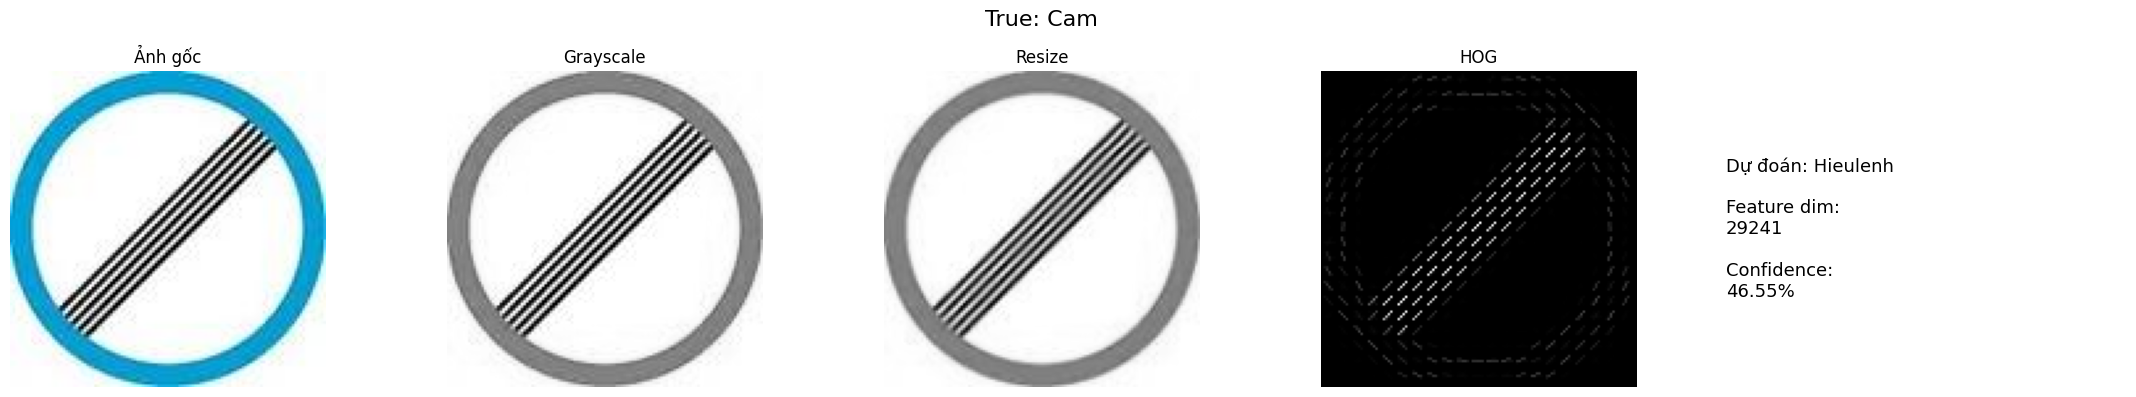

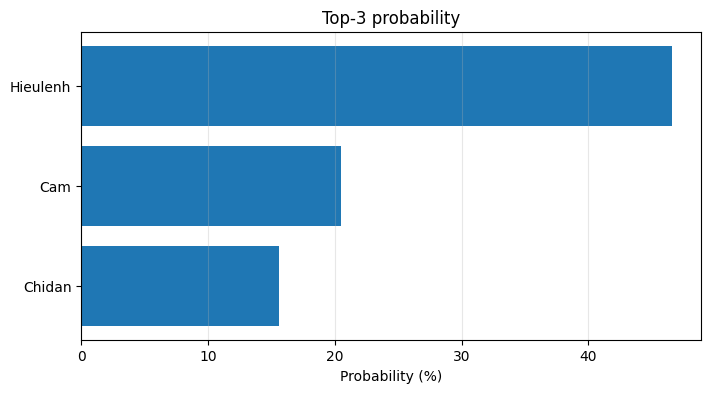

True: Cam | Pred: Hieulenh | File: Cam_15.jpg


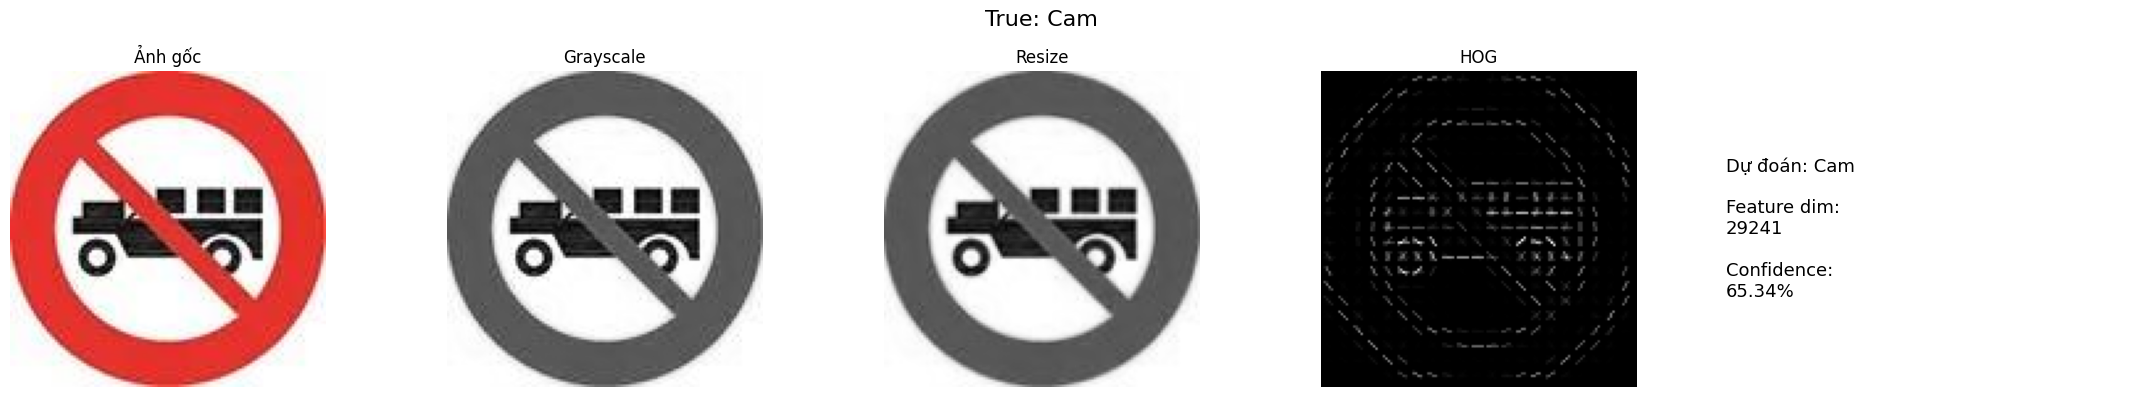

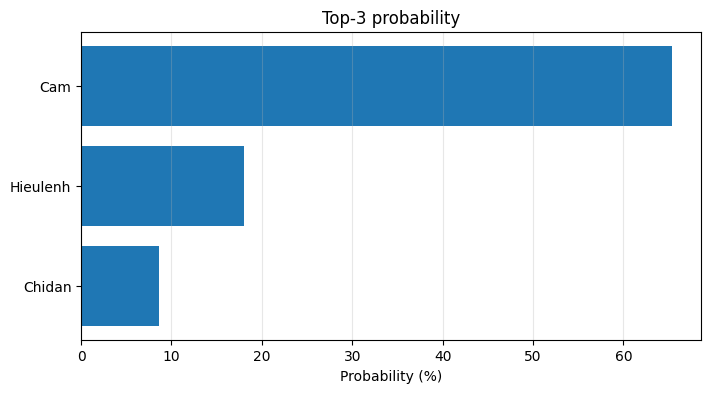

True: Cam | Pred: Cam | File: Cam_16.jpg


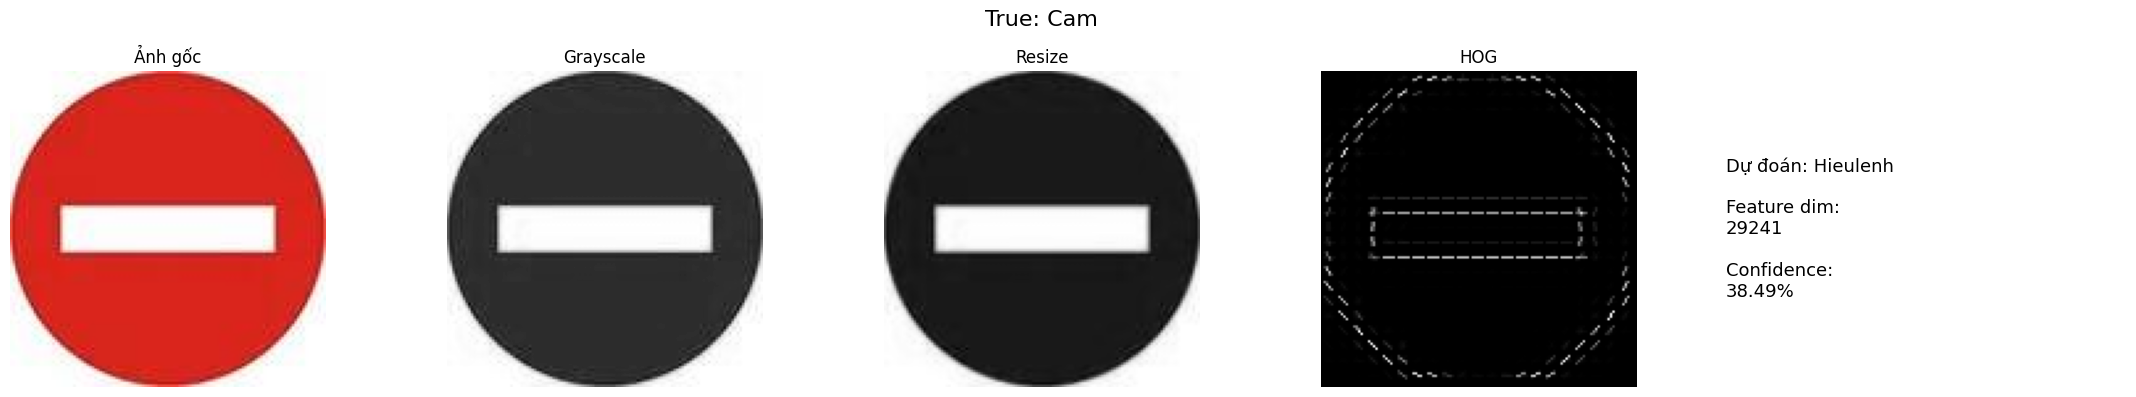

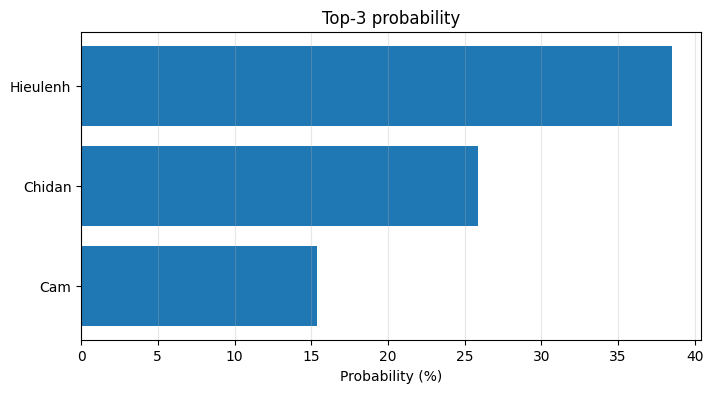

True: Cam | Pred: Hieulenh | File: Cam_17.jpg


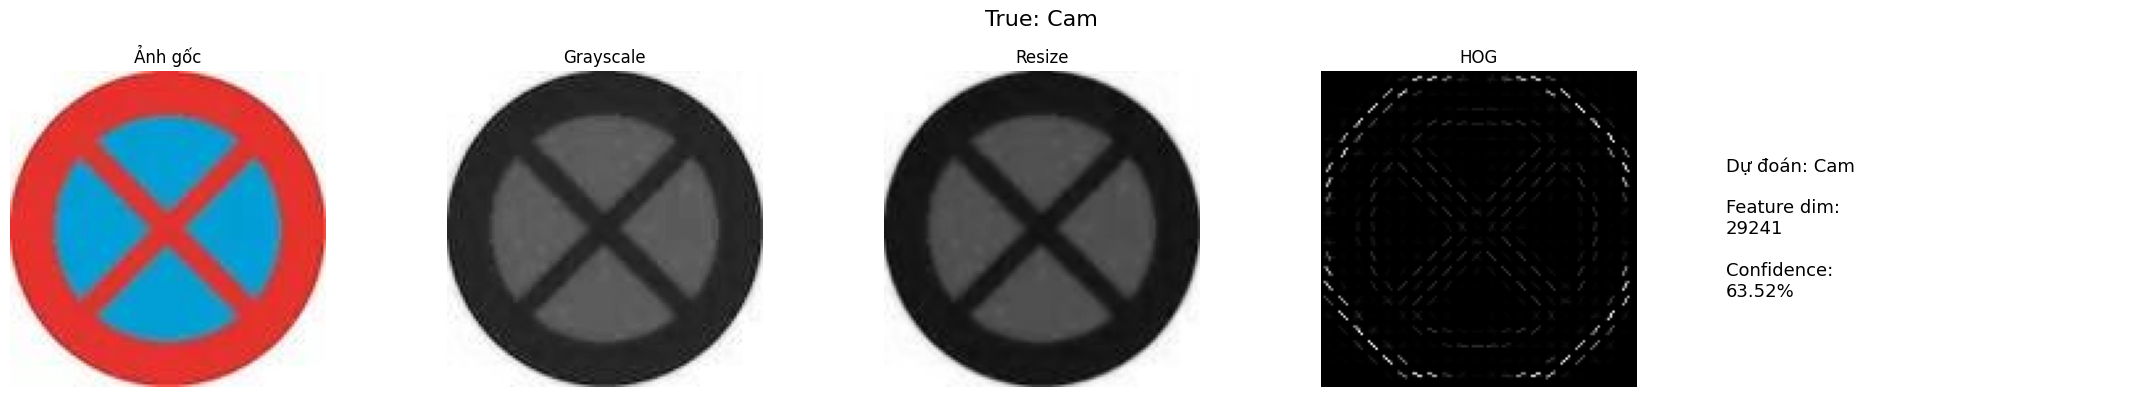

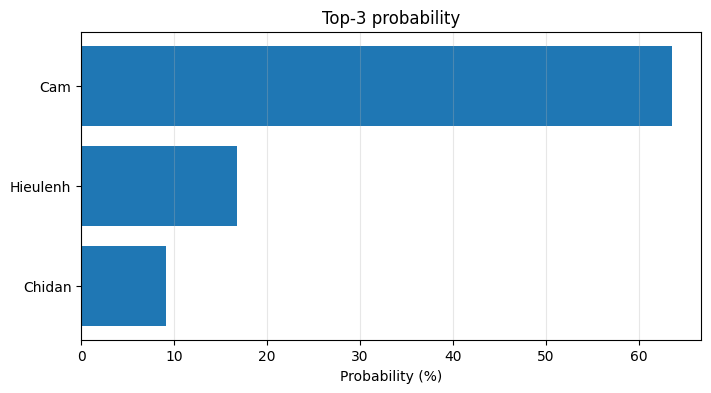

True: Cam | Pred: Cam | File: Cam_18.jpg


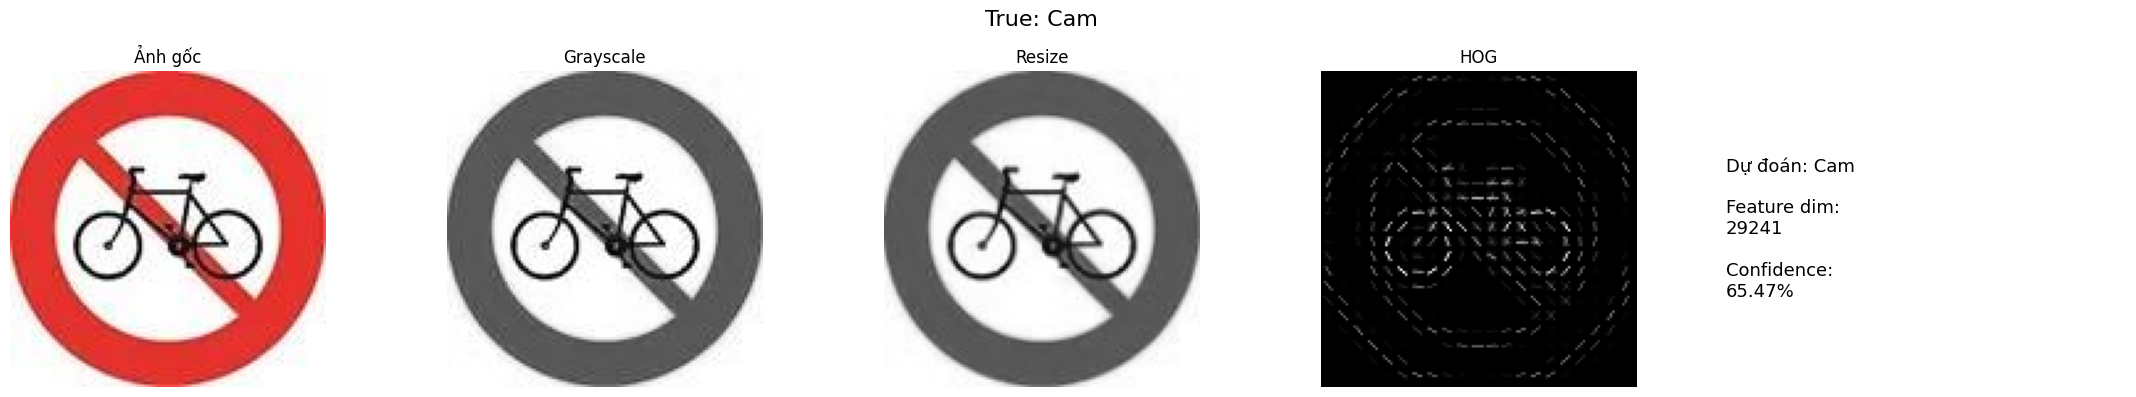

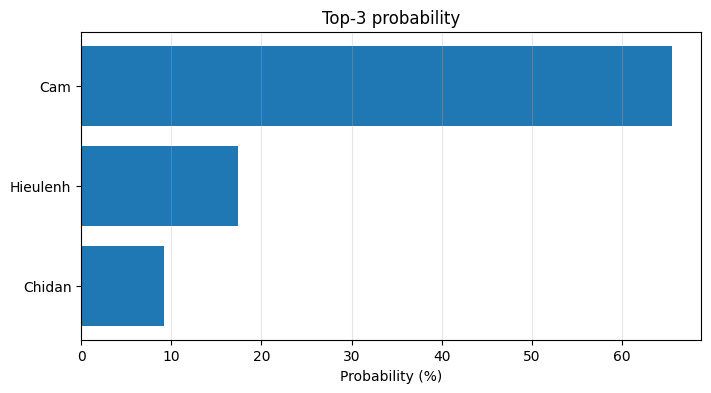

True: Cam | Pred: Cam | File: Cam_19.jpg


In [10]:
# Lấy tối đa n ảnh trong data/test để visualize nhanh
n_images = 6
image_paths = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
    image_paths.extend(TEST_DIR.rglob(ext))

image_paths = image_paths[:n_images]
print(f"Tìm thấy {len(image_paths)} ảnh để visualize")

for p in image_paths:
    true_label = p.parent.name
    pred = visualize_classification(
        p, model, le, IMAGE_SIZE, HOG_PARAMS,
        title=f"True: {true_label}",
        top_k=3
    )
    print(f"True: {true_label} | Pred: {pred} | File: {p.name}")

## 10. So sánh visualization score của 4 model trên cùng một ảnh

In [11]:
def extract_feature_for_payload(image_path, payload):
    img = imread(image_path)
    gray = rgb2gray(img) if img.ndim == 3 else img.astype(float)
    resized = resize(gray, payload["image_size"], anti_aliasing=True)
    feat = hog(resized, **payload["hog_params"])
    return feat.reshape(1, -1)

results = []
for key, fname in MODEL_FILES.items():
    model_path = MODELS_DIR / fname
    if not model_path.exists():
        print("Không thấy model:", model_path)
        continue

    pl = joblib.load(model_path)
    m = pl["model"]
    encoder = pl["label_encoder"]
    x_model = extract_feature_for_payload(IMAGE_PATH, pl)

    pred_enc = m.predict(x_model)[0]
    pred_label = encoder.inverse_transform([pred_enc])[0]
    scores, score_type = get_model_scores(m, x_model)

    confidence = None
    if scores is not None:
        confidence = scores[pred_enc]
        if score_type == "probability":
            confidence = confidence * 100

    results.append((key, pred_label, confidence, score_type))

print(f"Ảnh test: {IMAGE_PATH.name}")
print("-" * 80)
for key, pred_label, confidence, score_type in results:
    if confidence is None:
        print(f"{key:8s} | Pred: {pred_label}")
    else:
        suffix = "%" if score_type == "probability" else ""
        print(f"{key:8s} | Pred: {pred_label:25s} | {score_type}: {confidence:.4f}{suffix}")

e:\Nam_3_HK2\ThiGiac\DoAn\demo\.venv\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.3.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
e:\Nam_3_HK2\ThiGiac\DoAn\demo\.venv\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.3.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Ảnh test: Nguyhiem_3.jpeg
--------------------------------------------------------------------------------
RF_6x3   | Pred: Nguyhiem                  | probability: 51.3850%
RF_8x2   | Pred: Nguyhiem                  | probability: 57.5083%
SVM_6x3  | Pred: Nguyhiem                  | decision score: 4.2517
SVM_8x2  | Pred: Nguyhiem                  | decision score: 4.2554


e:\Nam_3_HK2\ThiGiac\DoAn\demo\.venv\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.3.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
e:\Nam_3_HK2\ThiGiac\DoAn\demo\.venv\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.3.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
